In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pickle

In [4]:
df = pd.read_csv('Students Social Media Addiction.csv')

df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [5]:
print(df.shape)

df.info()

df.isnull().sum()

(705, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  


,0
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


In [6]:
def kategori_risiko(score):

    if score <= 4:
        return "Rendah"

    elif score <= 7:
        return "Sedang"

    else:
        return "Tinggi"

df["Risk_Level"] = df["Addicted_Score"].apply(kategori_risiko)

df[["Addicted_Score","Risk_Level"]].head()

,Addicted_Score,Risk_Level
0,8,Tinggi
1,3,Rendah
2,9,Tinggi
3,4,Rendah
4,7,Sedang


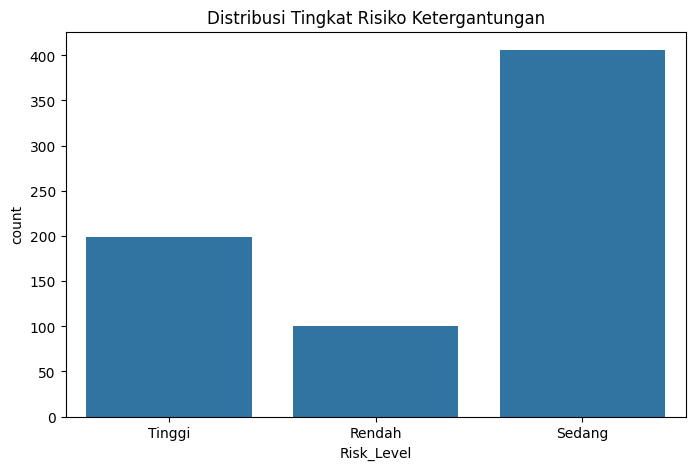

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="Risk_Level")

plt.title("Distribusi Tingkat Risiko Ketergantungan")
plt.show()

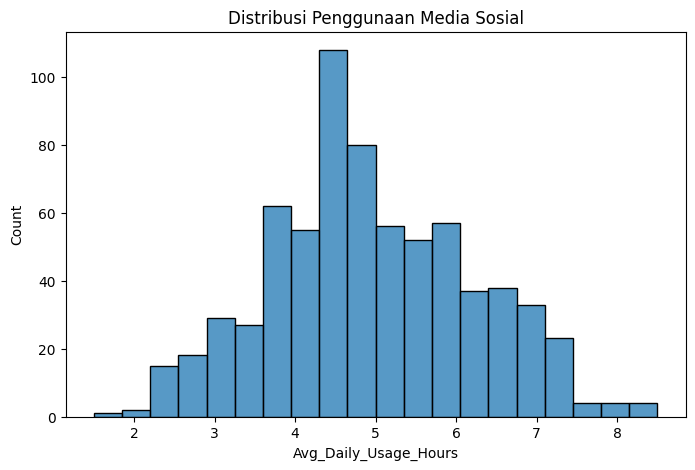

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["Avg_Daily_Usage_Hours"], bins=20)

plt.title("Distribusi Penggunaan Media Sosial")
plt.show()

In [9]:
le = LabelEncoder()

kolom_kategori = [
    'Gender',
    'Academic_Level',
    'Country',
    'Most_Used_Platform',
    'Affects_Academic_Performance',
    'Relationship_Status',
    'Risk_Level'
]

for col in kolom_kategori:
    df[col] = le.fit_transform(df[col])

In [10]:
X = df.drop([
    'Student_ID',
    'Addicted_Score',
    'Risk_Level'
], axis=1)

y = df['Risk_Level']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [13]:
pred = model.predict(X_test)

In [14]:
acc = accuracy_score(y_test,pred)

print("Accuracy :",acc)

Accuracy : 1.0


In [15]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        85
           2       1.00      1.00      1.00        38

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141



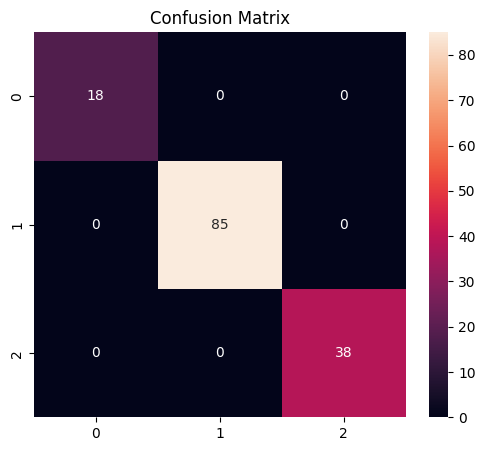

In [16]:
cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

In [17]:
pickle.dump(
    model,
    open('scrollsense_model.pkl','wb')
)

In [18]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                         Feature  Importance
10   Conflicts_Over_Social_Media    0.318371
8            Mental_Health_Score    0.303106
4          Avg_Daily_Usage_Hours    0.141074
7          Sleep_Hours_Per_Night    0.099315
3                        Country    0.037023
6   Affects_Academic_Performance    0.030911
5             Most_Used_Platform    0.027892
9            Relationship_Status    0.014524
0                            Age    0.012576
1                         Gender    0.008032
2                 Academic_Level    0.007177
